-----
# Sentence Transformers
-------

## Set Up
----

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords
import spacy

In [2]:
import torch
from torch.utils.data import DataLoader, TensorDataset

In [3]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

## Data Loading
----

In [4]:
emails_df = pd.read_csv('../../data/cleaned_emails.csv', index_col= 0)

In [5]:
emails_df['all_text'] = emails_df['cleaned_subject'] + ' ' + emails_df['cleaned_body']

In [6]:
nlp = spacy.load('en_core_web_sm')

In [7]:
def remove_names(text):
    text = str(text)
    doc = nlp(text)
    for e in reversed(doc.ents):
        if e.label_ in ("PERSON", "ORG", "DATE",): 
            text = text[:e.start_char] + text[e.start_char + len(e.text):]

    return text

In [8]:
emails_df['all_text'] = emails_df['all_text'].apply(remove_names)

## Get the Embeddings
----

In [9]:
model = SentenceTransformer("all-MiniLM-L6-v2")

In [10]:
embeddings = model.encode(
                emails_df['all_text'].tolist(),
                batch_size=32,             
                show_progress_bar=True,    
                convert_to_numpy=True  
            )

Batches:   0%|          | 0/938 [00:00<?, ?it/s]

In [11]:
embeddings

array([[ 0.01536653,  0.01287786, -0.01693478, ..., -0.00096158,
        -0.10146384,  0.01067386],
       [-0.0854864 ,  0.02039253,  0.01715118, ..., -0.02789755,
         0.06177846, -0.04930287],
       [-0.10973518,  0.0168007 ,  0.01082692, ..., -0.0401822 ,
        -0.07540251, -0.00978999],
       ...,
       [-0.05185171,  0.03555893, -0.02911534, ..., -0.03916322,
        -0.06432026, -0.01102137],
       [-0.06027867, -0.01843671, -0.02611239, ...,  0.03225156,
        -0.02134095, -0.00680135],
       [ 0.01418365, -0.04621974,  0.07918651, ...,  0.03811338,
        -0.08867104, -0.02909897]], dtype=float32)

In [12]:
print(embeddings.shape)

(30000, 384)


## Evaluating Embeddings
----

### Visualising the Embeddings

In [28]:
import umap.umap_ as umap
import matplotlib.pyplot as plt

In [29]:
# using umap to reduce dims, tsne not effective for these embeddings
umap_model = umap.UMAP(
    n_neighbors=5,    
    min_dist=0.1,      
    metric='cosine',   
    n_components=2,     
    random_state=12     
)

/Users/simybasra/anaconda3/envs/email_genie/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/simybasra/anaconda3/envs/email_genie/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


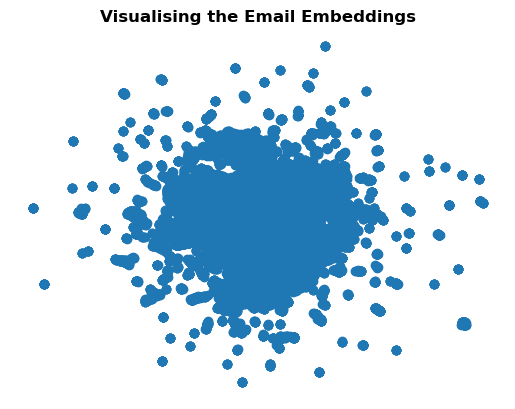

In [30]:
email_2d = umap_model.fit_transform(embeddings)

plt.scatter(email_2d[:, 0], email_2d[:, 1])
plt.title("Visualising the Email Embeddings", fontweight = 'bold')
plt.xticks([])
plt.yticks([])
plt.gca().spines[['top', 'bottom', 'right', 'left']].set_visible(False)
plt.show()

### Assessing Similarity Embeddings (IN PROGRESS)

In [15]:
# use cosine similarity to access similarity of embeddings
similarity_matrix = cosine_similarity(embeddings)

In [16]:
emails_df.reset_index(drop = True, inplace=True)

In [17]:
random_sample = emails_df.sample(20)
sample_indices = random_sample.index.tolist()
sample_embeddings = embeddings[sample_indices]

In [18]:
similarity_matrix = cosine_similarity(sample_embeddings)

In [19]:
similar_emails = []
dissimilar_emails = []

for i in range(len(sample_indices)):
    similarities = similarity_matrix[i]

    sorted_sims = similarities.argsort()[::-1]

    top_similar_indices = [idx for idx in sorted_sims if idx != i][:2]

    bottom_similar_indices = similarities.argsort()  # Ascending: least similar first
    top_dissimilar_indices = [idx for idx in bottom_similar_indices if idx != i][:2]
    
    similar_emails.append(random_sample.iloc[top_similar_indices]["all_text"].tolist())
    dissimilar_emails.append(random_sample.iloc[top_dissimilar_indices]["all_text"].tolist())



In [21]:
import textwrap

for i, idx in enumerate(random_sample.index):
    print('-' * 50)
    print(f"****** Sample Email #{i+1} *****")
    print("\nOriginal Email:")
    print(textwrap.fill(emails_df.loc[idx, "all_text"][:500], width=150)) 
    print("\nTop 2 Most Similar Emails:")
    for j, email in enumerate(similar_emails[i]):
        print(f"{j+1}. {textwrap.fill(email[:500], width=150)}\n")
    print("\nTop 2 Least Similar Emails:")
    for j, email in enumerate(dissimilar_emails[i]):
        print(f"{j+1}. {textwrap.fill(email[:500], width=150)}\n")


--------------------------------------------------
****** Sample Email #1 *****

Original Email:
eSource Presents LexisNexis Training eSource presents  training ADVANCED This session will cover advanced searching tips It will also cover using  to
narrow your search results Find out how to customize your desktop for easier searching Attend our   830 1000 AM EB572 PUBLIC RECORDS  is the premier
provider of public record information We will learn about materials available to you including Secretary of  and DBAs UCC filings  If you are doing
due diligence on companies especially smaller ones th

Top 2 Most Similar Emails:
1. Location Change Corporate Policy Committee Meeting Thursday Feb 22  please ensure I get to this Thxs Dave W DelaineyHOUECT on  PM  FastowHOUECT  Greg
Communications Ken  Communications  Susan  MarongeHOUECT  Liz M  Karen  Communications Dorothy    Please make note that this meeting will take place
in EB27C2 not EB30C1 as previously advised Your attendance at this meeti

## Clustering

In [66]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import DBSCAN

### K-means

In [80]:
scaler = MinMaxScaler()
scaled_embeddings = scaler.fit_transform(embeddings)

In [81]:
k_vals = np.arange(2,11,1)

In [82]:
# finding optimal k uisng scree plot
labels = []
inertia = []
silhouette_scores = []

for k in k_vals:
    kmeans = KMeans(n_clusters=k, random_state=11)
    kmeans.fit(scaled_embeddings)

    labels.append(kmeans.labels_)

    inertia.append(kmeans.inertia_)

    silhouette = silhouette_score(scaled_embeddings, kmeans.labels_)
    silhouette_scores.append(silhouette)

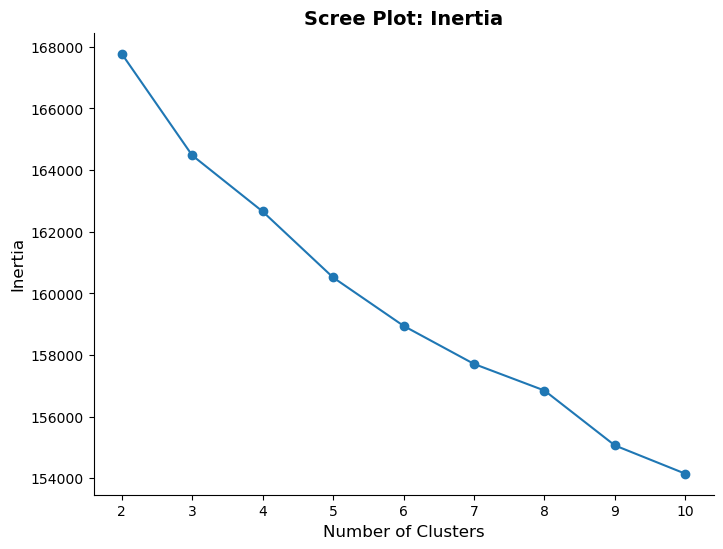

In [83]:
plt.figure(figsize=(8, 6))

plt.plot([k for k in k_vals], inertia, marker='o')
plt.title('Scree Plot: Inertia', fontsize=14, fontweight= 'bold')
plt.xlabel('Number of Clusters', fontsize=12)
plt.ylabel('Inertia', fontsize=12)
plt.gca().spines[['top', 'right']].set_visible(False)
plt.show()

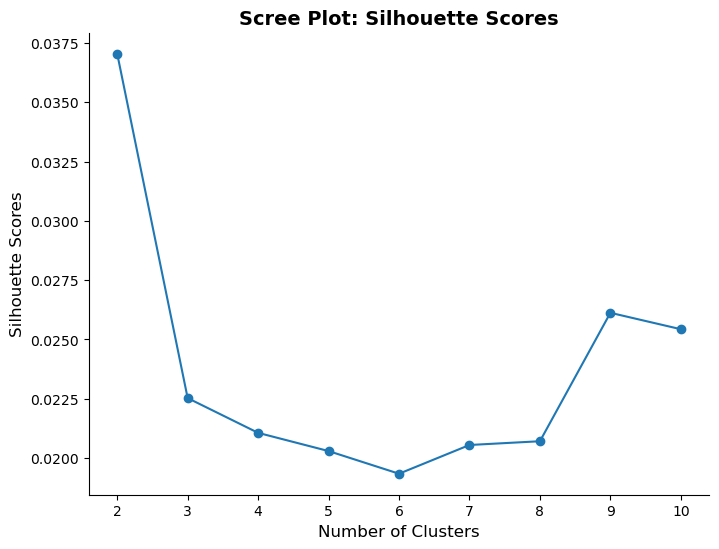

In [84]:
plt.figure(figsize=(8, 6))

plt.plot([k for k in k_vals], silhouette_scores, marker='o')
plt.title('Scree Plot: Silhouette Scores', fontsize=14, fontweight= 'bold')
plt.xlabel('Number of Clusters', fontsize=12)
plt.ylabel('Silhouette Scores', fontsize=12)
plt.gca().spines[['top', 'right']].set_visible(False)
plt.show()

In [85]:
kmeans = KMeans(n_clusters=3, random_state=11)
kmeans.fit(scaled_embeddings)

labels = kmeans.labels_

In [86]:
print(f"Inertia score: {kmeans.inertia_}")
print(f"Silhouette score: {silhouette_score(scaled_embeddings, kmeans.labels_)}")

Inertia score: 164479.578125
Silhouette score: 0.02252788469195366


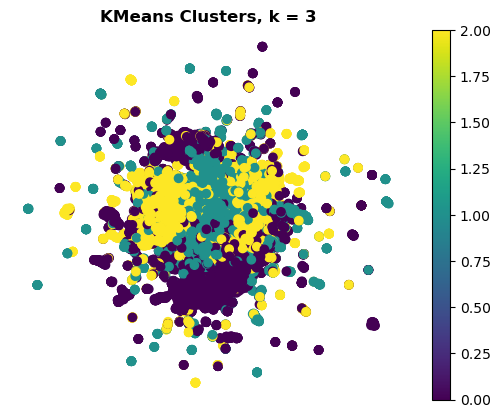

In [87]:
plt.scatter(email_2d[:, 0], email_2d[:, 1], c=labels, cmap='viridis')
plt.title("KMeans Clusters, k = 3", fontweight = 'bold')
plt.colorbar()
plt.xticks([])
plt.yticks([])
plt.gca().spines[['bottom', 'left','top', 'right']].set_visible(False)
plt.show()


In [89]:
k_means_labels = labels

-----
**Comment:**

Visible overlap between the different clusters, suggests there isnt a clear separation between the embeddings. A low silhouette score of 0.023 reflects this, a higher score means the clusters are well separated from each other. 

A high intertia score of 160_000 means the data points in the clusters are spread out and are not well separted at all. 

KMeans also assumes all clusters are spherical and this may not be true for noisy email data. The Enron dataset probably has clusters which all vary in shape and size. Even though sentence transformers are known to be more effective than BERT, the embeddings are still not fine-tuned to the dataset.

Perhaps its better to explore different clustering methods particularly those which do not assume spherical clusters. 

#### Assessing Clusters

In [101]:
for cluster in np.unique(k_means_labels):
    print(f"\n--- Samples from Cluster {cluster} ---")
    cluster_emails= np.where(k_means_labels == cluster)[0]

    for i in cluster_emails[:3]:
        wrapped_text = textwrap.fill(emails_df['all_text'][i], width=150)
        print(wrapped_text)
        print("-" * 40)


--- Samples from Cluster 0 ---
POSREP 24 OCT HOEGH GALLEON 24Oct 1200LT   at noon N37200 E010500 B Dist From last noon 422nm C Dist To go to next port 789nm D Next port ALGECIRAS
26Oct 1000 E 1 Av windsea Wind NW5 Sea NW5 2 Average speed 1758kn RPM 8855 3   FO Consumed 25 MT 6 GO Consumed 00  vapor press  Tk1  bar 15943 C Tk2
bar  C Tk3  bar  C Tk4 0050 bar  C Tk5  bar 15841 C  Master LNGC   telno  Fax Inmarsat fax no  Telex Inmarsat B telex no  Telex Inmarsat C telex no
24hrswatch
----------------------------------------
Re DASH today Sorry but I dont know Probably in the next 3 hours Maybe  will be around I have this feeling that I will be turning off the lights
tonight  what is the timing Im trying to catch a flight this afternoon   Smith Street EB 3817 Houston Texas 77002 Phone Fax
----------------------------------------
 and Internet Explorer 501 upgrade Houston On  a new version of  will be rolled out In order for this new version of The  to work you will need to
have Internet 

-----
**Comment:**

**Cluster 0: Operations**

This cluster seems to based around day-to-day operations like scheduling, browser updates and general logistics.

**Cluster 1: Legal**

These emails deal with formal business contracts, tax forms and documentation. It’s mostly legal or financial in nature, with a focus on compliance and approvals.

**Cluster 2: Incident Reports**

Emails here are longer and more detailed regarding updates about ongoing issues, projects or internal problems. They include things like repair status, blackout planning, and breakdowns in communication.


### HDBSCAN

Due to poor results from KMeans, I thought to use HDBSCAN. 

Unlike DBSCAN, HDBSCAN handles variable density clusters and doesn't require setting the number of clusters. This makes it better suited for noisy, high-dimensional data like Enron the dataset.

In [102]:
import hdbscan

/Users/simybasra/anaconda3/envs/email_genie/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/simybasra/anaconda3/envs/email_genie/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


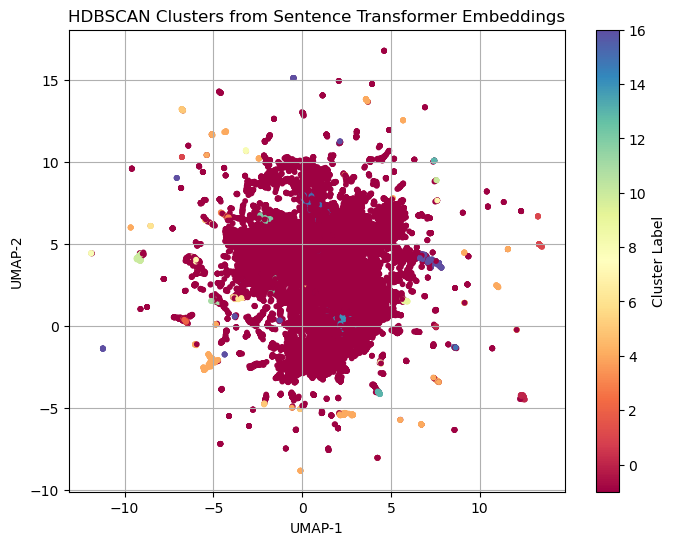

In [103]:
clusterer = hdbscan.HDBSCAN(min_cluster_size=30, cluster_selection_epsilon = 0.2, metric='euclidean')
labels = clusterer.fit_predict(scaled_embeddings)

plt.figure(figsize=(8, 6))
plt.scatter(email_2d[:, 0], email_2d[:, 1], c=labels, cmap='Spectral', s=10)
plt.colorbar(label='Cluster Label')
plt.title("HDBSCAN Clusters from Sentence Transformer Embeddings")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.grid(True)
plt.show()


----
**Comment:**

The plot shows that HDBSCAN identifies a large set of points as "noise," which suggests that many embeddings are very close to each other and don’t form well-defined groups. The clusters that do form appear quite sparse and spread out. Given the relatively high number of clusters, it’s likely that some of these clusters are not particularly meaningful or useful.

Sentence Transfomers can struggle with generic emails which are inevitble and so may not capture subtlties unless fine-tuned.

#### Insepecting Clusters

In [122]:
pd.Series(labels).value_counts()

-1     28000
 4       445
 0       256
 15      226
 12      148
 10      141
 16      140
 14      120
 5        91
 13       77
 2        63
 6        60
 1        45
 8        40
 3        40
 9        38
 7        37
 11       33
Name: count, dtype: int64

----
**Comment:**

As seen in the plot, majority of the emails are clustered as noise (-1 label). 

For now, this cluster will be excluded since it doesn’t provide meaningful grouping. 

Instead, we will focus on analysing the other clusters to better understand how well the emails have been grouped.

In [104]:
hbdscan_labels = labels[labels != -1]# removing the noise as we don't want to see thesee meails

In [ ]:
label_counts = pd.Series(hbdscan_labels).value_counts()

4     445
0     256
15    226
12    148
10    141
16    140
14    120
5      91
13     77
2      63
6      60
1      45
8      40
3      40
9      38
7      37
11     33
Name: count, dtype: int64


----
**Comment:**

Ignoring clusters with fewer than 100 emails, as these smaller clusters may be noisy or contain outliers, it seems that having 17 clusters in total is a bit excessive for this project, in my opinion.

In [120]:
valid_clusters = label_counts[label_counts >= 100].index

In [121]:
for cluster in np.unique(valid_clusters):
    print(f"\n--- Samples from Cluster {cluster} ---")
    cluster_emails= np.where(valid_clusters == cluster)[0] 

    for i in cluster_emails[:3]:
        wrapped_text = textwrap.fill(emails_df['all_text'][i][:500], width=150)
        print(wrapped_text)
        print("-" * 40)



--- Samples from Cluster 0 ---
 Refining LLC Yolanda In connection with the execution of the ISDA Master Agreement with  requires that they provide the following documentation 1
Form W9 Request for Taxpayer Identification Number 2 Certificate of Incumbency certifying i a true and correct copy of the certificate of organization
or formation and operating agreement and ii the incumbency and specimen signature of the officer executing the  on behalf of the sole membermanager of
Secretary of  Refining certifying resolutions aut
----------------------------------------

--- Samples from Cluster 4 ---
POSREP 24 OCT HOEGH GALLEON 24Oct 1200LT   at noon N37200 E010500 B Dist From last noon 422nm C Dist To go to next port 789nm D Next port ALGECIRAS
26Oct 1000 E 1 Av windsea Wind NW5 Sea NW5 2 Average speed 1758kn RPM 8855 3   FO Consumed 25 MT 6 GO Consumed 00  vapor press  Tk1  bar 15943 C Tk2
bar  C Tk3  bar  C Tk4 0050 bar  C Tk5  bar 15841 C  Master LNGC   telno  Fax Inmarsat fax no  Tele

----
**Comment:**

**Cluster 0: Legal** 

Contains emails related to formal business documentation and legal agreements, such as ISDA Master Agreements and certification paperwork.

**Cluster 4: Operations**

Represents operational messages, including shipping or reports on location or status

**Cluster 10 Informal**

Includes casual communications, internal updates or personal messages with references to timing and travel plans.

**Cluster 12 Legal/Finance**

Centred around contract management and purchase agreements, highlighting transactional or negotiation communications.

**Cluster 14 IT/Tech:** 

Focuses on technical updates or IT-related messages, such as software upgrades and system requirements.

**Cluster 15 Operations:**

Contains progress or status updates about operational activities, including repair assessments and resource allocation.

**Cluster 16 Tax:** 

Relates to tax-related communications, specifically regarding tax treaties and jurisdictional considerations.



## Summary
------

Overall, there is noticeable overlap between emails across clusters, but this was expected—TF-IDF results had already hinted that emails often touch on multiple general topics. This is a common challenge with email data, where a single message can reference operations, legal matters, and financial details all at once.

Despite this, the clustering results align reasonably well with the initial TF-IDF findings, which suggested three main topic areas: Operations, Legal, and Finance. These themes emerged again in both KMeans and HDBSCAN evaluations, indicating that the Sentence Transformer embeddings are capturing some meaningful structure in the data.

However, the Sentence Transformer model was not fine-tuned on the Enron dataset. As a result, many brief or generic emails—which make up a large portion of the dataset—may not be well-represented in the embedding space. This likely contributed to the large "noise" cluster in HDBSCAN.

Finally, it’s important to remember that the UMAP plots used for visualisation may not represent the actual vector space well. The whole purpose of UMAP is to reduce the dimensions of the embeddings, so clusters may be distorted. 

Moving forward, I plan to use these embeddings to explore classification!